# Radiology Assistant: End-to-End Evaluation (Zip-Ready)

### Instructions for Colab:
1. **Upload your Zip**: Upload your project zip file to the Colab `/content` folder (using the folder icon on the left).
2. **Set Secrets**: Click the **🔑 (Secrets)** icon and add:
   - `OPENAI_API_KEY`, `HF_TOKEN`, `KAGGLE_USERNAME`, `KAGGLE_KEY`.
3. **Run Cells**: The first code cell will automatically find and unzip your project.

In [1]:
# 1. Unzip and Robust Path Setup
import os, sys, zipfile, shutil
from pathlib import Path

# Find the uploaded zip file in /content
zips = list(Path('/content').glob('*.zip'))
if not zips:
    print("No zip file found in /content. Assuming files are already present.")
    REPO_ROOT = Path.cwd()
else:
    zip_path = zips[0]
    extract_to = Path('/content/extracted_project')
    print(f"Unzipping {zip_path.name} to {extract_to}...")
    if extract_to.exists(): shutil.rmtree(extract_to)
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)

    # Robustly find the directory containing 'src'
    # This handles nested folders or __MACOSX garbage
    src_dirs = list(extract_to.rglob('src'))
    if src_dirs:
        # The parent of the 'src' folder is our REPO_ROOT
        REPO_ROOT = src_dirs[0].parent
        print(f"Detected REPO_ROOT at: {REPO_ROOT}")
    else:
        REPO_ROOT = extract_to
        print(f"Warning: 'src' folder not found. Using {REPO_ROOT} as root.")

# CRITICAL: Add the 'src' directory to sys.path so 'bda_chest' can be found
SRC_PATH = str(REPO_ROOT / "src")
if SRC_PATH not in sys.path:
    sys.path.insert(0, SRC_PATH)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print(f"Python path updated. Searching for modules in: {SRC_PATH}")

# Verify bda_chest exists
if (REPO_ROOT / "src" / "bda_chest").exists():
    print("✅ Found 'bda_chest' package.")
else:
    print("❌ ERROR: 'bda_chest' package not found in expected location.")

# Install Dependencies
!pip install -q "transformers<5.0.0" "accelerate>=0.25" "bitsandbytes>=0.43.0" "evaluate>=0.4.0" "rouge_score>=0.1.2" kaggle python-dotenv openai Pillow timm

from google.colab import userdata
os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')
os.environ["HF_TOKEN"] = userdata.get('HF_TOKEN')
os.environ["KAGGLE_USERNAME"] = userdata.get('KAGGLE_USERNAME')
os.environ["KAGGLE_KEY"] = userdata.get('KAGGLE_KEY')
os.environ["TOKENIZERS_PARALLELISM"] = "false"

Unzipping Big_Data_Analytics_Midterm_Project.zip to /content/extracted_project...
Detected REPO_ROOT at: /content/extracted_project/Big_Data_Analytics_Midterm_Project
Python path updated. Searching for modules in: /content/extracted_project/Big_Data_Analytics_Midterm_Project/src
✅ Found 'bda_chest' package.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 129.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 45.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 48.3 MB/s eta 0:00:00


In [2]:
# 2. Import Your Trained Pipeline
try:
    from bda_chest.pipeline import load_inference_bundle, infer_from_pil
    from bda_chest.llm import answer_question_about_report
    print("✅ Successfully imported project modules.")
except ImportError as e:
    print(f"❌ Import Error: {e}")
    print("Current sys.path:", sys.path)
    raise

# Find checkpoint
CHECKPOINT_PATH = REPO_ROOT / "eva_x_tiny_binary_best.pt"
if not CHECKPOINT_PATH.exists():
    # Try alternative locations if it's missing from root
    alt_path = list(REPO_ROOT.rglob("eva_x_tiny_binary_best.pt"))
    if alt_path:
        CHECKPOINT_PATH = alt_path[0]
    else:
        raise FileNotFoundError(f"Checkpoint not found at {CHECKPOINT_PATH}.")

bundle = load_inference_bundle(CHECKPOINT_PATH, device_hint="cuda")
print(f"Trained EVA-X model loaded from {CHECKPOINT_PATH}")

✅ Successfully imported project modules.
Trained EVA-X model loaded from /content/extracted_project/Big_Data_Analytics_Midterm_Project/eva_x_tiny_binary_best.pt


In [3]:
# 3. Define Evaluation Judge (Gemma 2-2B)
import json, torch
from transformers import AutoModelForCausalLM, AutoTokenizer

class MedGemmaJudge:
    def __init__(self, model_id="google/gemma-2-2b-it"):
        print(f"Loading Judge: {model_id}...")
        self.tokenizer = AutoTokenizer.from_pretrained(model_id)

        if torch.cuda.is_available():
            self.model = AutoModelForCausalLM.from_pretrained(
                model_id,
                torch_dtype=torch.float16,
                device_map="auto",
                attn_implementation="eager"
            )
        else:
            self.model = AutoModelForCausalLM.from_pretrained(
                model_id,
                device_map="cpu",
                torch_dtype=torch.float32
            )
        self.model.eval()

    def evaluate(self, q, a, c, gt):
        # Medical Persona Prompt
        prompt = f"You are a senior radiologist evaluator. Assess the AI's answer for clinical accuracy.\n\nContext: {str(c)[:500]}\nQuestion: {q}\nAnswer: {str(a)[:500]}\nGround Truth: {gt}\n\nTask: Return a JSON object with:\n- \"correctness_score\": an integer 1-5\n- \"justification\": a brief clinical explanation.\n\nResponse:"

        messages = [{"role": "user", "content": prompt}]
        text_input = self.tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

        inputs = self.tokenizer(text_input, return_tensors="pt").to(self.model.device)

        with torch.no_grad():
            outputs = self.model.generate(
                **inputs,
                max_new_tokens=256,
                do_sample=True,
                temperature=0.2,
                top_p=0.9,
                pad_token_id=self.tokenizer.eos_token_id
            )

        return self.tokenizer.decode(outputs[0][inputs.input_ids.shape[1]:], skip_special_tokens=True).strip()

In [4]:
# 4. Download Kaggle Test Data
from kaggle.api.kaggle_api_extended import KaggleApi
import random

api = KaggleApi(); api.authenticate()
test_img_path = Path("/content/eval_test_images")
if not test_img_path.exists():
    api.dataset_download_files("paultimothymooney/chest-xray-pneumonia", path="/content/temp_kaggle", unzip=True)
    for cat in ["NORMAL", "PNEUMONIA"]:
        dest = test_img_path / cat.lower(); dest.mkdir(parents=True, exist_ok=True)
        imgs = list(Path("/content/temp_kaggle/chest_xray/test").joinpath(cat).glob("*.jpeg"))
        for i in random.sample(imgs, 30): shutil.copy(i, dest / i.name)
    shutil.rmtree("/content/temp_kaggle")
print("Test images ready at /content/eval_test_images")

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
Test images ready at /content/eval_test_images


In [8]:
# 6. Question Answering Evaluation (ROUGE & BLEU)
import json
import evaluate
from PIL import Image
import pandas as pd

# Load your actual QA test dataset
qa_json_path = REPO_ROOT / "qa_test_samples.json"

if not qa_json_path.exists():
    print(f"❌ ERROR: Could not find {qa_json_path}")
else:
    print(f"✅ Loading QA dataset from {qa_json_path}")
    with open(qa_json_path, 'r') as f:
        qa_samples = json.load(f)

    try:
        rouge_metric = evaluate.load('rouge')
        bleu_metric = evaluate.load('bleu')
    except Exception as e:
        print(f"Could not load metrics: {e}")

    qa_results = []
    preds = []
    refs = []

    print(f"Evaluating {len(qa_samples)} QA samples...")
    for i, sample in enumerate(qa_samples):
        try:
            # Adjust path resolution depending on how your JSON stores paths
            # Assuming it's relative to REPO_ROOT (e.g. "test_images/normal/...")
            img_path = REPO_ROOT / sample.get('image_path', '')
            if not img_path.exists():
                print(f"Warning: Image not found at {img_path}")
                continue

            img = Image.open(img_path).convert("RGB")
            q = sample.get('question', 'Are there signs of pneumonia?')

            # FIX: Use 'ground_truth' instead of 'answer' based on JSON structure
            ref_answer = sample.get('ground_truth', '')

            # Pipeline Inference
            payload, _ = infer_from_pil(bundle, img)
            pred_answer = answer_question_about_report(payload, q)

            preds.append(pred_answer)
            refs.append(ref_answer)

            qa_results.append({
                "image": img_path.name,
                "question": q,
                "reference_answer": ref_answer,
                "predicted_answer": pred_answer
            })

            print(f"\n[{i+1}/{len(qa_samples)}] Q: {q}")
            print(f"   Ref:  {ref_answer}")
            print(f"   Pred: {pred_answer}")

        except Exception as e:
            print(f"Error processing sample {i}: {e}")

    if preds:
        # Compute Scores
        bleu_refs = [[r] for r in refs] # BLEU expects a list of lists for references
        rouge_scores = rouge_metric.compute(predictions=preds, references=refs)
        bleu_scores = bleu_metric.compute(predictions=preds, references=bleu_refs)

        print("\n" + "="*35)
        print("📝 QA TEXT GENERATION METRICS")
        print("="*35)
        print(f"ROUGE-1: {rouge_scores['rouge1']:.4f}")
        print(f"ROUGE-2: {rouge_scores['rouge2']:.4f}")
        print(f"ROUGE-L: {rouge_scores['rougeL']:.4f}")
        print(f"BLEU:    {bleu_scores['bleu']:.4f}")
        print("="*35)

        display(pd.DataFrame(qa_results))
    else:
        print("No successful predictions to evaluate.")

✅ Loading QA dataset from /content/extracted_project/Big_Data_Analytics_Midterm_Project/qa_test_samples.json
Evaluating 10 QA samples...

[1/10] Q: Does this patient have pneumonia?
   Ref:  No, the lungs are clear. There is no evidence of pneumonia, consolidation, or effusion.
   Pred: No, this patient does not have pneumonia. The chest X-ray impression is normal, and the probability of abnormality is very low (0.0019), well below the threshold for concern.

[2/10] Q: Does this patient have pneumonia?
   Ref:  No, the lungs are clear. There is no evidence of pneumonia, consolidation, or effusion.
   Pred: No, this patient does not have pneumonia. The chest X-ray impression is normal, and the probability of abnormality is low (approximately 7%), which is below the threshold for concern. Therefore, there is no indication of pneumonia in this case.

[3/10] Q: Does this patient have pneumonia?
   Ref:  No, the lungs are clear. There is no evidence of pneumonia, consolidation, or effusion.

,image,question,reference_answer,predicted_answer
0,NORMAL2-IM-0112-0001.jpeg,Does this patient have pneumonia?,"No, the lungs are clear. There is no evidence ...","No, this patient does not have pneumonia. The ..."
1,NORMAL2-IM-0359-0001.jpeg,Does this patient have pneumonia?,"No, the lungs are clear. There is no evidence ...","No, this patient does not have pneumonia. The ..."
2,NORMAL2-IM-0325-0001.jpeg,Does this patient have pneumonia?,"No, the lungs are clear. There is no evidence ...","No, this patient does not have pneumonia. The ..."
3,NORMAL2-IM-0373-0001.jpeg,Does this patient have pneumonia?,"No, the lungs are clear. There is no evidence ...","Yes, this patient has a high-confidence pneumo..."
4,NORMAL2-IM-0221-0001.jpeg,Does this patient have pneumonia?,"No, the lungs are clear. There is no evidence ...","Yes, this patient has a high-confidence pneumo..."
5,person1650_virus_2852.jpeg,What findings suggest an abnormality in this i...,The image shows focal opacification or consoli...,The findings suggest an abnormality due to a h...
6,person3_virus_16.jpeg,What findings suggest an abnormality in this i...,The image shows focal opacification or consoli...,The findings suggest an abnormality due to a h...
7,person136_bacteria_654.jpeg,What findings suggest an abnormality in this i...,The image shows focal opacification or consoli...,The findings suggest an abnormality due to a h...
8,person130_bacteria_628.jpeg,What findings suggest an abnormality in this i...,The image shows focal opacification or consoli...,The findings suggest an abnormality due to a h...
9,person1_virus_9.jpeg,What findings suggest an abnormality in this i...,The image shows focal opacification or consoli...,The image shows a high-confidence pneumonia-li...


Starting Evaluation...

[1/60] NORMAL2-IM-0332-0001.jpeg
   GT: NORMAL | Pred: NORMAL (0.1548)
   Judge: ```json
{
  "correctness_score": 5,
  "justification": "The AI correctly identifies that the chest X...

[2/60] NORMAL2-IM-0317-0001.jpeg
   GT: NORMAL | Pred: NORMAL (0.0036)
   Judge: ```json
{
  "correctness_score": 5,
  "justification": "The AI correctly identifies that there are n...

[3/60] NORMAL2-IM-0319-0001.jpeg
   GT: NORMAL | Pred: NORMAL (0.0203)
   Judge: ```json
{
  "correctness_score": 5,
  "justification": "The AI correctly identifies that the chest X...

[4/60] NORMAL2-IM-0316-0001.jpeg
   GT: NORMAL | Pred: PNEUMONIA (0.9904)
   Judge: ```json
{
  "correctness_score": 1,
  "justification": "The AI's answer is incorrect. The ground tru...

[5/60] NORMAL2-IM-0370-0001.jpeg
   GT: NORMAL | Pred: NORMAL (0.0027)
   Judge: ```json
{
  "correctness_score": 5,
  "justification": "The AI correctly identifies that the chest X...

[6/60] NORMAL2-IM-0045-0001.jpeg
   GT: NOR

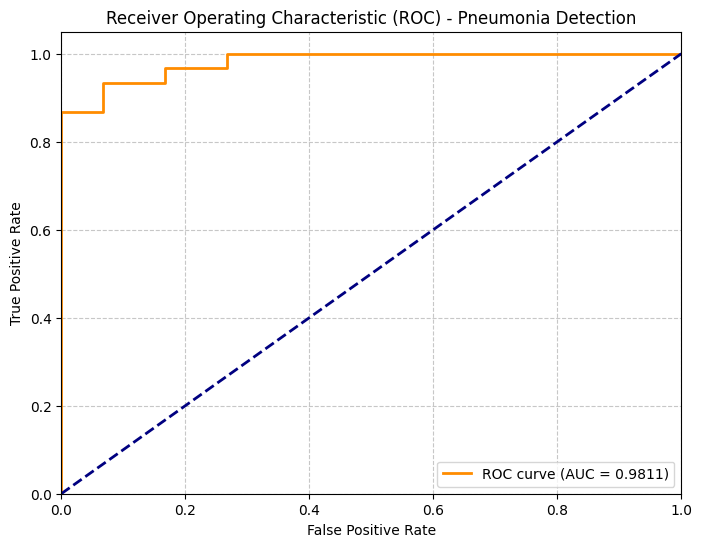


--- Detailed Results ---


,filename,ground_truth,prediction,judge_score
0,NORMAL2-IM-0332-0001.jpeg,NORMAL,NORMAL,5
1,NORMAL2-IM-0317-0001.jpeg,NORMAL,NORMAL,5
2,NORMAL2-IM-0319-0001.jpeg,NORMAL,NORMAL,5
3,NORMAL2-IM-0316-0001.jpeg,NORMAL,PNEUMONIA,1
4,NORMAL2-IM-0370-0001.jpeg,NORMAL,NORMAL,5
5,NORMAL2-IM-0045-0001.jpeg,NORMAL,NORMAL,5
6,NORMAL2-IM-0341-0001.jpeg,NORMAL,NORMAL,5
7,NORMAL2-IM-0335-0001.jpeg,NORMAL,PNEUMONIA,1
8,NORMAL2-IM-0059-0001.jpeg,NORMAL,NORMAL,5
9,NORMAL2-IM-0329-0001.jpeg,NORMAL,NORMAL,5


In [10]:
# 5. Comprehensive Evaluation Loop
from PIL import Image
import torch
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, roc_curve, auc
import evaluate

# Ensure judge is initialized (Restart session if CUDA error persists)
try:
    if 'judge' not in globals():
        judge = MedGemmaJudge()
except Exception as e:
    print(f"Could not initialize judge: {e}")

# Load NLP Metrics
try:
    rouge_metric = evaluate.load('rouge')
    bleu_metric = evaluate.load('bleu')
except Exception as e:
    print(f"Could not load NLP metrics: {e}")
    rouge_metric, bleu_metric = None, None

# Configuration
CONFIDENCE_THRESHOLD = 0.5
results = []

print("Starting Evaluation...")
test_files = list(test_img_path.rglob("*.jpeg"))

for i, path in enumerate(test_files):
    try:
        img = Image.open(path).convert("RGB")
        ground_truth_label = path.parent.name.upper() # NORMAL or PNEUMONIA
        q = "Are there signs of pneumonia?"

        # Synthesize a reference answer for BLEU/ROUGE based on GT
        if ground_truth_label == "PNEUMONIA":
            reference_answer = "Yes, there are signs of pneumonia."
        else:
            reference_answer = "No, there are no signs of pneumonia."

        # --- Stage 1: Classification ---
        payload, prob = infer_from_pil(bundle, img, threshold=CONFIDENCE_THRESHOLD)
        prediction_label = payload['prediction']

        # --- Stage 2: QA / Reasoning ---
        answer = answer_question_about_report(payload, q)

        # --- Stage 3: Clinical Critique (Judge) ---
        # Truncate inputs to prevent OOM/Asserts
        feedback = judge.evaluate(q, answer, payload['impression'][:500], f"Verify if the report matches the diagnosis of {ground_truth_label}.")

        # Parse feedback for score (simple heuristic)
        score = 0
        if "correctness_score" in feedback:
            try:
                # extract number from JSON-like string
                import re
                match = re.search(r'"correctness_score":\s*(\d)', feedback)
                if match:
                    score = int(match.group(1))
            except: pass

        # Store Result
        results.append({
            "filename": path.name,
            "ground_truth": ground_truth_label,
            "prediction": prediction_label,
            "probability": prob,
            "assistant_answer": answer,
            "reference_answer": reference_answer,
            "judge_feedback": feedback,
            "judge_score": score
        })

        print(f"\n[{i+1}/{len(test_files)}] {path.name}")
        print(f"   GT: {ground_truth_label} | Pred: {prediction_label} ({prob:.4f})")
        print(f"   Judge: {feedback[:100]}...")

    except Exception as e:
        print(f"Error processing {path.name}: {e}")
        if "device-side assert" in str(e).lower():
            print("CRITICAL: GPU state corrupted. Please Restart Session.")
            break

# --- Metrics Calculation ---
if results:
    df = pd.DataFrame(results)

    # Binary Metrics
    y_true = df['ground_truth']
    y_pred = df['prediction']
    y_prob = df['probability']

    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary', pos_label='PNEUMONIA')

    print("\n" + "="*30)
    print("📊 FINAL EVALUATION REPORT")
    print("="*30)
    print(f"Total Samples: {len(df)}")
    print(f"Accuracy:      {acc:.4f}")
    print(f"Precision:     {prec:.4f}")
    print(f"Recall:        {rec:.4f}")
    print(f"F1 Score:      {f1:.4f}")

    # ROC Curve Generation
    y_true_binary = (y_true == 'PNEUMONIA').astype(int)
    fpr, tpr, thresholds = roc_curve(y_true_binary, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) - Pneumonia Detection')
    plt.legend(loc="lower right")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

    # NLP Metrics Calculation
    if rouge_metric and bleu_metric:
        preds = df['assistant_answer'].tolist()
        refs = df['reference_answer'].tolist()
        bleu_refs = [[r] for r in refs] # Bleu expects list of lists for references

        rouge_scores = rouge_metric.compute(predictions=preds, references=refs)
        bleu_scores = bleu_metric.compute(predictions=preds, references=bleu_refs)

        print("\n--- NLP Metrics (Synthesized References) ---")
        print(f"ROUGE-1:       {rouge_scores['rouge1']:.4f}")
        print(f"ROUGE-L:       {rouge_scores['rougeL']:.4f}")
        print(f"BLEU:          {bleu_scores['bleu']:.4f}")

    print("\n--- Detailed Results ---")
    display(df[['filename', 'ground_truth', 'prediction', 'judge_score']])
else:
    print("No results collected.")